Why XGBoost is Powerful - Each new tree learns from previous errors.

(in this project XGBoost is not installed/issue due to laptop restriction, so gradientBoosting method is used instead of xgboost)

✅ Works well on tabular data

✅ Handles non-linear relationships

✅ Feature importance

✅ Regularization

✅ Missing value handling

✅ Often wins Kaggle competitions

✅ Widely used in industry


XGBoost Project: Telecom Customer Churn Prediction
Business Problem

A telecom company wants to predict which customers are likely to leave.

This helps them:

Offer discounts
Improve customer retention
Reduce revenue loss

target:
Churn

0 = Stay
1 = Leave


features:
Age
MonthlyCharges
Tenure
SupportTickets
InternetUsage
ContractLength

import libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

2. create dataset

In [4]:
np.random.seed(42)

n = 5000

age = np.random.randint(18,70,n)

monthly_charges = np.random.randint(500,5000,n)

tenure = np.random.randint(1,72,n)

support_tickets = np.random.randint(0,15,n)

internet_usage = np.random.randint(50,1000,n)

contract_length = np.random.randint(1,36,n)

churn = (
    (monthly_charges > 3500).astype(int)
    + (support_tickets > 7).astype(int)
    + (tenure < 12).astype(int)
    + (contract_length < 12).astype(int)
)

churn = (churn >= 3).astype(int)

df = pd.DataFrame({
    "Age": age,
    "MonthlyCharges": monthly_charges,
    "Tenure": tenure,
    "SupportTickets": support_tickets,
    "InternetUsage": internet_usage,
    "ContractLength": contract_length,
    "Churn": churn
})

df.head()

,Age,MonthlyCharges,Tenure,SupportTickets,InternetUsage,ContractLength,Churn
0,56,2420,18,6,625,18,0
1,69,3991,33,13,857,16,0
2,46,3644,1,1,793,16,0
3,32,2593,6,7,100,23,0
4,60,675,41,1,186,22,0


Cell 3: Quick EDA

In [5]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["Churn"].value_counts())

print("\nStatistics:")
print(df.describe())

Shape: (5000, 7)

Missing Values:
Age               0
MonthlyCharges    0
Tenure            0
SupportTickets    0
InternetUsage     0
ContractLength    0
Churn             0
dtype: int64

Target Distribution:
Churn
0    4586
1     414
Name: count, dtype: int64

Statistics:
               Age  MonthlyCharges       Tenure  SupportTickets  \
count  5000.000000     5000.000000  5000.000000      5000.00000   
mean     43.584600     2760.453800    35.860000         6.98660   
std      14.919094     1297.411298    20.391321         4.37116   
min      18.000000      501.000000     1.000000         0.00000   
25%      31.000000     1611.250000    18.000000         3.00000   
50%      43.000000     2775.500000    36.000000         7.00000   
75%      56.000000     3873.000000    53.000000        11.00000   
max      69.000000     4998.000000    71.000000        14.00000   

       InternetUsage  ContractLength        Churn  
count    5000.000000     5000.000000  5000.000000  
mean      521.5640

Cell 4: Target Distribution

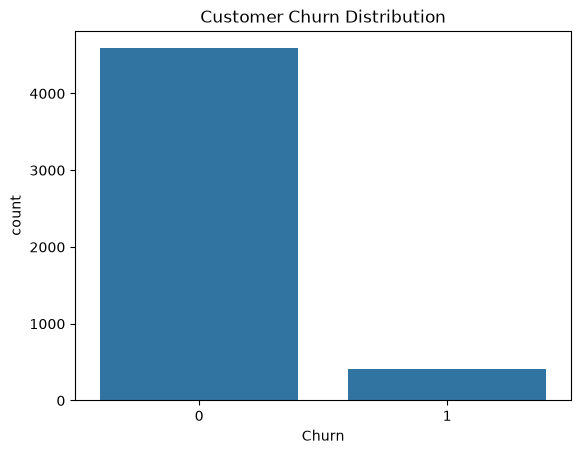

In [6]:
sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.show()


Cell 5: Correlation Heatmap

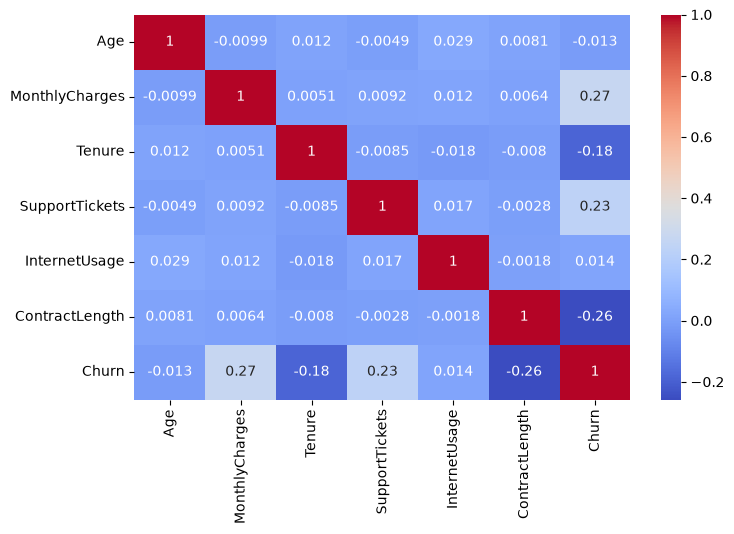

In [7]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Cell 6: Features and Target

In [8]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

Cell 7: Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Cell 8: Train Gradient Boosting

No scaling required.

In [10]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

Cell 9: Predictions

In [11]:
y_pred = gb.predict(X_test)

y_prob = gb.predict_proba(X_test)[:,1]

print(y_pred)
print("\n")
print(y_prob)

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 

Cell 10: Evaluation

In [12]:
print("Accuracy :",
      accuracy_score(y_test,y_pred))

print("Precision:",
      precision_score(y_test,y_pred))

print("Recall   :",
      recall_score(y_test,y_pred))

print("F1 Score :",
      f1_score(y_test,y_pred))

print("ROC AUC  :",
      roc_auc_score(y_test,y_prob))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


Cell 11: Confusion Matrix

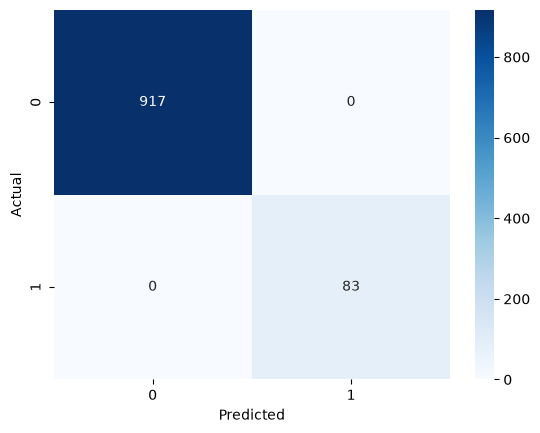

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Cell 12: Classification Report

In [14]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       917
           1       1.00      1.00      1.00        83

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



Cell 13: Feature Importance, Visualization:

          Feature  Importance
1  MonthlyCharges    0.259188
3  SupportTickets    0.255403
5  ContractLength    0.251242
2          Tenure    0.233108
4   InternetUsage    0.001059
0             Age    0.000000


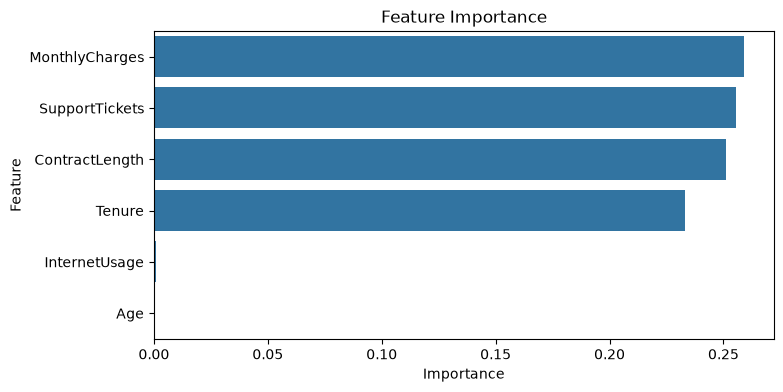

In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,4))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

Cell 14: Hyperparameter Tuning

In [16]:
params = {
    "n_estimators":[100,200],
    "learning_rate":[0.01,0.1,0.2],
    "max_depth":[3,5,7]
}

grid = GridSearchCV(
    GradientBoostingClassifier(
        random_state=42
    ),
    params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


Cell 15: Best Model

In [17]:
best_gb = grid.best_estimator_

y_pred_best = best_gb.predict(
    X_test
)

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       917
           1       1.00      1.00      1.00        83

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



Cell 16: Train vs Test Score

In [18]:
print(
    "Train Score:",
    best_gb.score(
        X_train,
        y_train
    )
)

print(
    "Test Score:",
    best_gb.score(
        X_test,
        y_test
    )
)

Train Score: 1.0
Test Score: 1.0


Cell 17: Predict New Customer

In [19]:
new_customer = pd.DataFrame({
    "Age":[28],
    "MonthlyCharges":[4200],
    "Tenure":[5],
    "SupportTickets":[10],
    "InternetUsage":[800],
    "ContractLength":[6]
})

prediction = best_gb.predict(
    new_customer
)

probability = best_gb.predict_proba(
    new_customer
)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Prediction: 1
Probability: [9.36312082e-07 9.99999064e-01]
